Self-consistent Delta0 = 0.0712079345
20.67534899711609 seconds


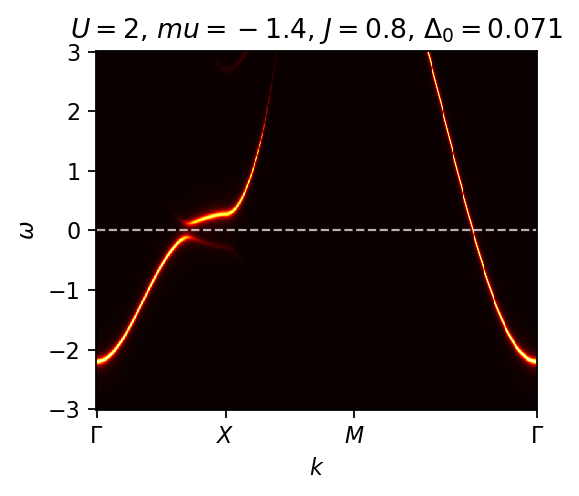

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
import time

start_time = time.time()

def lorentzian(x, gamma):
    """Normalized Lorentzian used to broaden delta functions."""
    return gamma / np.pi / (x**2 + gamma**2)


def state_index(occ):
    """Map |n_a, n_b, n_c, n_d> to the integer Fock index."""
    return sum(int(n) << i for i, n in enumerate(occ))


def annihilation_operator(mode, n_modes=4):
    """Fermionic annihilation matrix for one mode in the occupation basis."""
    dim = 2**n_modes
    op = np.zeros((dim, dim), dtype=complex)

    for state in range(dim):
        if not ((state >> mode) & 1):
            continue

        new_state = state & ~(1 << mode)
        occupied_before = sum((state >> j) & 1 for j in range(mode))
        sign = (-1) ** occupied_before
        op[new_state, state] = sign

    return op


def thermal_weights(energies, beta):
    """Boltzmann weights normalized in a numerically stable way."""
    shifted = energies - np.min(energies)
    weights = np.exp(-beta * shifted)
    return weights / np.sum(weights)


def band_energy(kx, ky, mu, hop):
    """
    Dispersion used in wormsc.py:

        xi_k = -2(cos kx + cos ky)
               -4 t1 cos kx cos ky
               -4 t2(cos^2 kx + cos^2 ky - 1) - mu.
    """
    cx = np.cos(kx)
    cy = np.cos(ky)
    t1, t2 = hop
    return (
        -2.0 * (cx + cy)
        - 4.0 * t1 * cx * cy
        - 4.0 * t2 * (cx * cx + cy * cy - 1.0)
        - mu
    )


def pair_form_factor(kx, ky):
    """d-wave form factor cos(kx) - cos(ky)."""
    return np.cos(kx) - np.cos(ky)


def block_matrix_elements(kx, ky, mu, hop, U, Delta0):
    """
    Construct the block matrices for one four-mode Fermi-arc sector.

    Mode order:
        0: a = c_{k up}
        1: b = c_{k+Q down}
        2: c = c_{-k down}
        3: d = c_{-k-Q up}

    Basis convention:
        |n_a, n_b, n_c, n_d>

    The d-wave relations Delta_{-k}=Delta_k and Delta_{k+Q}=-Delta_k
    have already been used, so only Delta_k appears below.
    """
    xi_k = band_energy(kx, ky, mu, hop)
    xi_kq = band_energy(kx + np.pi, ky + np.pi, mu, hop)
    Delta_k = Delta0 * pair_form_factor(kx, ky)
    d = Delta_k
    dc = np.conjugate(Delta_k)

    h_sz_2 = np.array([[xi_k + xi_kq]], dtype=complex)
    basis_sz_2 = [(1, 0, 0, 1)]

    h_sz_minus_2 = np.array([[xi_k + xi_kq]], dtype=complex)
    basis_sz_minus_2 = [(0, 1, 1, 0)]

    h_sz_1_a = np.array(
        [
            [xi_k, dc],
            [d, xi_k + 2.0 * xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_1_a = [(1, 0, 0, 0), (1, 1, 0, 1)]

    h_sz_1_d = np.array(
        [
            [xi_kq, dc],
            [d, 2.0 * xi_k + xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_1_d = [(0, 0, 0, 1), (1, 0, 1, 1)]

    h_sz_minus_1_b = np.array(
        [
            [xi_kq, -dc],
            [-d, 2.0 * xi_k + xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_minus_1_b = [(0, 1, 0, 0), (1, 1, 1, 0)]

    h_sz_minus_1_c = np.array(
        [
            [xi_k, -dc],
            [-d, xi_k + 2.0 * xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_minus_1_c = [(0, 0, 1, 0), (0, 1, 1, 1)]

    h_sz_0_4 = np.array(
        [
            [0.0, dc, dc, 0.0],
            [d, 2.0 * xi_k, 0.0, -dc],
            [d, 0.0, 2.0 * xi_kq, -dc],
            [0.0, -d, -d, 2.0 * (xi_k + xi_kq + U)],
        ],
        dtype=complex,
    )
    basis_sz_0_4 = [
        (0, 0, 0, 0),
        (1, 0, 1, 0),
        (0, 1, 0, 1),
        (1, 1, 1, 1),
    ]

    h_interacting_pair = np.array([[xi_k + xi_kq + U]], dtype=complex)
    basis_ab = [(1, 1, 0, 0)]
    basis_cd = [(0, 0, 1, 1)]

    return [
        (h_sz_2, basis_sz_2),
        (h_sz_1_a, basis_sz_1_a),
        (h_sz_1_d, basis_sz_1_d),
        (h_sz_0_4, basis_sz_0_4),
        (h_interacting_pair, basis_ab),
        (h_interacting_pair, basis_cd),
        (h_sz_minus_1_b, basis_sz_minus_1_b),
        (h_sz_minus_1_c, basis_sz_minus_1_c),
        (h_sz_minus_2, basis_sz_minus_2),
    ]


def diagonalize_sector_block(kx, ky, mu, hop, U, Delta0):
    """
    Diagonalize all blocks and embed their eigenvectors into the full
    16-dimensional occupation basis of one four-mode sector.
    """
    energies_all = []
    vectors_all = []

    for h_block, basis_occ in block_matrix_elements(kx, ky, mu, hop, U, Delta0):
        energies, vectors = np.linalg.eigh(h_block)
        basis_indices = [state_index(occ) for occ in basis_occ]

        for n in range(len(energies)):
            full_vector = np.zeros(16, dtype=complex)
            full_vector[basis_indices] = vectors[:, n]
            energies_all.append(energies[n])
            vectors_all.append(full_vector)

    order = np.argsort(np.real(energies_all))
    energies_all = np.array(energies_all, dtype=float)[order]
    vectors_all = np.array(vectors_all, dtype=complex).T[:, order]

    return energies_all, vectors_all


def sector_operators():
    """
    Return annihilation operators and the d-wave pair operator in one sector.

    pair-annihilation operator is pair = c_{-k down} * c_{k up}

    """
    c_ops = [annihilation_operator(i) for i in range(4)]
    pair_op = c_ops[2] @ c_ops[0]
    return c_ops, pair_op


C_OPS, PAIR_OP = sector_operators()


def pair_expectation_for_k(kx, ky, mu, hop, U, Delta0, beta):
    """Thermal expectation value of c_{-k down} c_{k up}."""
    energies, vectors = diagonalize_sector_block(kx, ky, mu, hop, U, Delta0)
    rho = thermal_weights(energies, beta)
    pair_eigenbasis = vectors.conj().T @ PAIR_OP @ vectors
    return np.sum(rho * np.diag(pair_eigenbasis))


def triangular_kmesh(nk1d):
    """Triangular k mesh 0 <= ky <= kx <= pi, matching the reduced symmetry region."""
    points = []
    weights = []
    for ix in range(nk1d):
        for iy in range(ix + 1):
            kx = ix * np.pi / nk1d
            ky = iy * np.pi / nk1d
            points.append((kx, ky))
            weights.append(0.5 if ix == iy else 1.0)
    return np.array(points, dtype=float), np.array(weights, dtype=float)


def solve_gap_delta0(k_points, k_weights, J, mu, hop, U, beta, bracket=(1e-8, 1.0)):
    """
    Solve a simple d-wave gap equation for Delta0 using scipy.root_scalar:

        Delta0 = -J < g_k <c a> >_triangular_mesh.

    """

    def new_delta(delta0):
        vals = []
        for (kx, ky), weight in zip(k_points, k_weights):
            gk = pair_form_factor(kx, ky)
            vals.append(weight * gk * pair_expectation_for_k(kx, ky, mu, hop, U, delta0, beta))
        return -J * np.sum(vals) / np.sum(k_weights)

    def residual(delta0):
        return np.real(new_delta(delta0) - delta0)

    lo, hi = bracket
    f_lo = residual(lo)
    f_hi = residual(hi)
    while f_lo * f_hi > 0 and hi < 20.0:
        hi *= 2.0
        f_hi = residual(hi)

    if f_lo * f_hi > 0:
        return 0.0

    sol = optimize.root_scalar(residual, bracket=(lo, hi), xtol=1e-10, rtol=1e-10)
    return sol.root


def spectral_function_for_k_block(
    kx,
    ky,
    omega_values,
    mu,
    hop,
    U,
    Delta0,
    beta,
    gamma,
    mode=0,
):
    """
    Compute A(k, omega) in one four-mode sector using the Lehmann formula.

    mode=0 corresponds to c_{k up}.
    mode=1 corresponds to c_{k+Q down}.
    mode=2 corresponds to c_{-k down}.
    mode=3 corresponds to c_{-k-Q up}.
    """
    energies, vectors = diagonalize_sector_block(kx, ky, mu, hop, U, Delta0)
    rho = thermal_weights(energies, beta)

    c_op = C_OPS[mode]
    cd_op = c_op.conj().T

    c_eigenbasis = vectors.conj().T @ c_op @ vectors
    cd_eigenbasis = vectors.conj().T @ cd_op @ vectors

    spectrum = np.zeros_like(omega_values, dtype=float)

    for m, e_m in enumerate(energies):
        for n, e_n in enumerate(energies):
            addition_weight = rho[m] * abs(cd_eigenbasis[n, m]) ** 2
            removal_weight = rho[m] * abs(c_eigenbasis[n, m]) ** 2

            spectrum += addition_weight * lorentzian(omega_values - (e_n - e_m), gamma)
            spectrum += removal_weight * lorentzian(omega_values + (e_n - e_m), gamma)

    return spectrum


def k_path_gamma_x_m_gamma(numk):
    """Return k-points and path distance for Gamma-X-M-Gamma."""
    gamma_pt = np.array([0.0, 0.0])
    x_pt = np.array([np.pi, 0.0])
    m_pt = np.array([np.pi, np.pi])

    k_gx = np.linspace(gamma_pt, x_pt, numk, endpoint=False, axis=1)
    k_xm = np.linspace(x_pt, m_pt, numk, endpoint=False, axis=1)
    k_mg = np.linspace(m_pt, gamma_pt, numk + 1, axis=1)
    kpath = np.hstack((k_gx, k_xm, k_mg))

    klen = np.zeros(kpath.shape[1])
    for i in range(1, klen.size):
        klen[i] = klen[i - 1] + np.linalg.norm(kpath[:, i] - kpath[:, i - 1])

    xticks = [
        0.0,
        np.linalg.norm(x_pt - gamma_pt),
        np.linalg.norm(x_pt - gamma_pt) + np.linalg.norm(m_pt - x_pt),
        klen[-1],
    ]
    xlabels = [r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$"]
    return kpath, klen, xticks, xlabels


def fermi_arc_spectral_function_path(kpath, omega_values, mu, hop, U, Delta0, beta, gamma, mode=0):
    """Compute spectral weight along a k path."""
    spectral_weight = np.zeros((len(omega_values), kpath.shape[1]), dtype=float)

    for i in range(kpath.shape[1]):
        spectral_weight[:, i] = spectral_function_for_k_block(
            kpath[0, i],
            kpath[1, i],
            omega_values,
            mu=mu,
            hop=hop,
            U=U,
            Delta0=Delta0,
            beta=beta,
            gamma=gamma,
            mode=mode,
        )

    return spectral_weight


# Model and plotting parameters, chosen to match the earlier Fermi-arc code.
hop = np.array([-0.2, 0.1])
# mu = 4.0 * (hop[0] - hop[1])
# mu = -0.674
# mu = -1.2
# mu = -1.6
# mu = -1
mu = -1.4
U = 2
J = 0.8
# J = 1.2

temperature = 1e-10 * J
beta = 1.0 / temperature
gamma = 0.04

# Set this to True if you want the script to solve a self-consistent Delta0.
use_self_consistent_delta = True
# Delta0 = 0.0

if use_self_consistent_delta:
    k_points, k_weights = triangular_kmesh(64)
    Delta0 = solve_gap_delta0(k_points, k_weights, J, mu, hop, U, beta, bracket=(1e-8, J))
    print(f"Self-consistent Delta0 = {Delta0:.10f}")

numk = 200
# omegas = np.linspace(-2.5, 2.5, 500)
omegas = np.linspace(-3, 3, 600)
kpath, klen, xticks, xlabels = k_path_gamma_x_m_gamma(numk)

spectral_weight = fermi_arc_spectral_function_path(
    kpath,
    omegas,
    mu=mu,
    hop=hop,
    U=U,
    Delta0=Delta0,
    beta=beta,
    gamma=gamma,
    mode=0,
)

vmax = np.percentile(spectral_weight, 99)

plt.figure(figsize=(3.6, 3.2), dpi=160)
plt.pcolormesh(klen, omegas, spectral_weight, shading="auto", cmap="hot")
# plt.colorbar(label=r"$A(\mathbf{k},\omega)$")
plt.xticks(xticks, xlabels)
plt.xlabel(r"$k$")
plt.ylabel(r"$\omega$")
plt.title(rf"$U={U}$, $mu={mu}$, $J={J}$, $\Delta_0={Delta0:.3f}$")
plt.tight_layout()
end_time = time.time()
print(end_time - start_time, "seconds")
line_x = [0, klen[-1]]
line_y = [0, 0]
plt.plot(line_x, line_y, color='white', linestyle='--', linewidth=1, alpha=0.7)
# plt.savefig("fermi_arc_superconducting_spectral_function_block.png", bbox_inches="tight")
# np.save(f'sc_spectrum_U={U}_mu={mu}J={J}', spectral_weight)
# plt.close()
